In [1]:
!pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import json
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, balanced_accuracy_score

In [3]:
visus_folder_name = 'visualizations'
os.makedirs(visus_folder_name, exist_ok=True)
visus_path = os.path.join(os.getcwd(), visus_folder_name)

In [4]:
base_path = "evaluation"
cenarios = ["zero-shot", "few-shot"]
dados = []

for cenario in cenarios:
    cenario_path = os.path.join(base_path, cenario)
    
    for root, dirs, files in os.walk(cenario_path):
        for file in files:
            if file == "individual_metrics.json":
                file_path = os.path.join(root, file)
                
                with open(file_path, "r") as f:
                    metrics = json.load(f)
                
                for modelo, valores in metrics.items():
                    dados.append({
                        "cenario": cenario,
                        "modelo": modelo,
                        **valores
                    })

df_individuals = pd.DataFrame(dados)

model_short_names = {
    'gemma-3-gaia-pt-br-4b-it': 'Gemma 3 Gaia (4B)',
    'mixtral-8x7b-instruct-v01': 'Mixtral v01 (8×7B)',
    'sabia-3.1': 'Sabia 3.1',
    'granite-3-3-8b-instruct': 'Granite 3.3 (8B)',
    'gemini-2.5-flash': 'Gemini 2.5 Flash',
    'gpt-4': 'GPT-4',
    'llama-3-405b-instruct': 'LLaMA 3 (405B)',
    'deepseek-r1-0528-qwen3-8b': 'DeepSeek R1 (8B)',
    'gervasio-7b-portuguese-ptbr-decoder': 'Gervasio (7B)'
}

df_individuals['modelo'] = df_individuals['modelo'].apply(lambda model_name: model_short_names[model_name])

# excluindo desta análise os modelos mixtral e gervasio por enquanto
df_individuals = df_individuals[~df_individuals['modelo'].str.contains('mixtral|gervasio', case=False, na=False)]
df_individuals.head(3)

,cenario,modelo,punchlines,comic_styles,texts_explanations
0,zero-shot,Gemma 3 Gaia (4B),[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...
2,zero-shot,Sabia 3.1,[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...
3,zero-shot,Granite 3.3 (8B),[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...


In [5]:
def expand_dict_column(df, dict_col):
    df = df.copy()
    df[dict_col] = df[dict_col].apply(
        lambda x: x if isinstance(x, list) else [x] if isinstance(x, dict) else []
    )

    expanded_rows = []
    for _, row in df.iterrows():
        for item in row[dict_col]:
            if isinstance(item, dict):
                expanded_rows.append({
                    "scenario": row["cenario"],
                    **item
                })

    return pd.DataFrame(expanded_rows)

df_punchlines = expand_dict_column(df_individuals, "punchlines")
df_comic_styles = expand_dict_column(df_individuals, "comic_styles")
df_texts_explanations = expand_dict_column(df_individuals, "texts_explanations")
df_texts_explanations['agreement_level'] = df_texts_explanations['judge_model_results'].apply(lambda judge_model_result: int(judge_model_result['nivel_concordancia']))

### Erros e acertos em comum 

In [6]:
MIN_MODELS_REPEATS = 5

WORSE_PUNCHLINES_THRESHOLD = 0.4
BETTER_PUNCHLINES_THRESHOLD = 0.6

WORSE_EXPLANATIONS_THRESHOLD = 2
BETTER_EXPLANATIONS_THRESHOLD = 4

##### Punchlines Identification

In [7]:
df_punchlines_worse = df_punchlines[df_punchlines['dice_similarity'] <= WORSE_PUNCHLINES_THRESHOLD]
df_punchlines_better = df_punchlines[df_punchlines['dice_similarity'] >= BETTER_PUNCHLINES_THRESHOLD]

##### Humor Reasoning

In [8]:
df_explanations_worse = df_texts_explanations[df_texts_explanations['agreement_level'] <= WORSE_EXPLANATIONS_THRESHOLD]
df_explanations_better = df_texts_explanations[df_texts_explanations['agreement_level'] <= BETTER_EXPLANATIONS_THRESHOLD]

##### Comic Styles Classification

In [9]:
df = df_comic_styles.copy()
rows = []

for (model, scenario, style), group in df.groupby(['model_name', 'scenario', 'comic_style']):
    y_true = group['true_label']
    y_pred = group['pred_label']
    
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    
    rows.append({
        'model_name': model,
        'scenario': scenario,
        'comic_style': style,
        'f1_0': report['0']['f1-score'],
        'f1_1': report['1']['f1-score'],
        'f1_macro': report['macro avg']['f1-score'],
        'balanced_accuracy': bal_acc
    })

results = pd.DataFrame(rows)
results['model_name'] = results['model_name'].apply(lambda model_name: model_short_names[model_name])
# excluindo desta análise os modelos mixtral e gervasio por enquanto
results = results[~results['model_name'].str.contains('mixtral|gervasio', case=False, na=False)]

In [10]:
results['model_name'].unique()

array(['DeepSeek R1 (8B)', 'Gemini 2.5 Flash', 'Gemma 3 Gaia (4B)',
       'GPT-4', 'Granite 3.3 (8B)', 'LLaMA 3 (405B)', 'Sabia 3.1'],
      dtype=object)

In [11]:
model_order = [
    'Gemini 2.5 Flash',
    'GPT-4',
    'Sabia 3.1',
    'LLaMA 3 (405B)',
    'Granite 3.3 (8B)',
    'Gemma 3 Gaia (4B)',
    'DeepSeek R1 (8B)'
]

# 2. Converta a coluna 'model_name' para um tipo categórico com a ordem definida
results['model_name'] = pd.Categorical(results['model_name'], categories=model_order, ordered=True)

In [12]:
results['comic_style'].unique()

array(['cynicism', 'fun', 'humor', 'irony', 'nonsense', 'sarcasm',
       'satire', 'wit'], dtype=object)

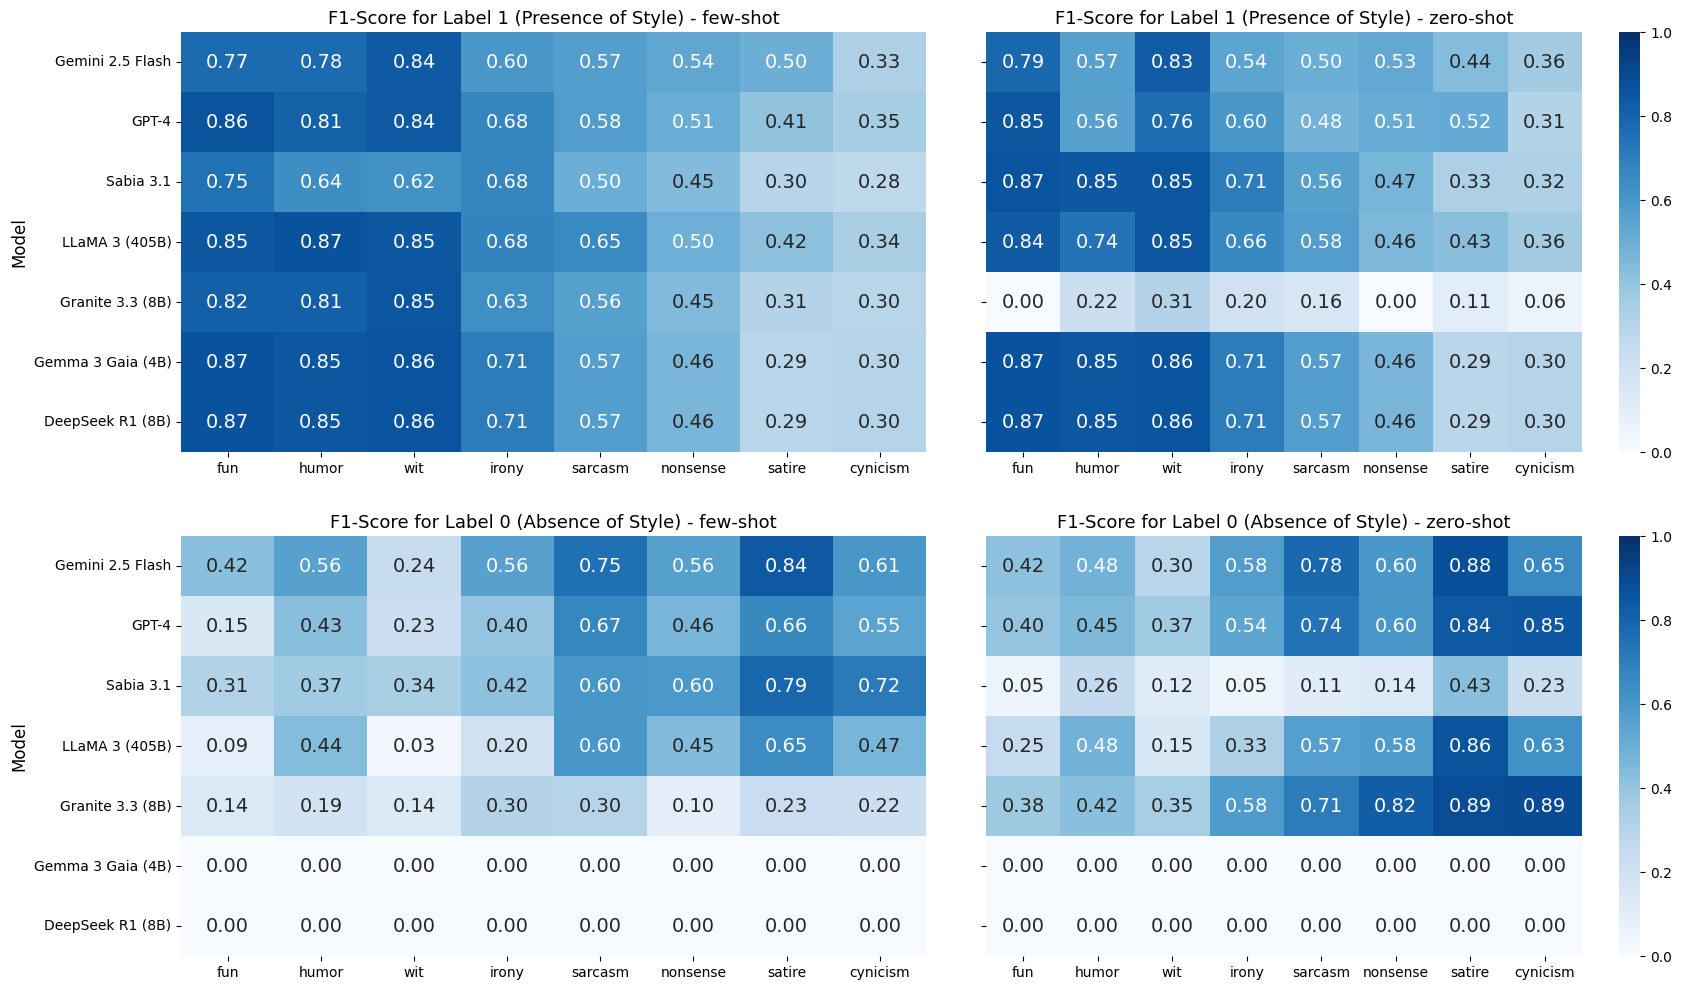

In [13]:

# ==================================================================

# O código de plotagem com a alteração
# O código de plotagem com a alteração
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 12), sharey=True)
f1_info = [('f1_1', 'Label 1 (Presence of Style)'), ('f1_0', 'Label 0 (Absence of Style)')]
scenarios = results['scenario'].unique()
style_order = ['fun', 'humor', 'wit', 'irony', 'sarcasm', 'nonsense', 'satire', 'cynicism']

for row_idx, (f1_class, title) in enumerate(f1_info):
    for col_idx, scenario in enumerate(scenarios):
        ax = axes[row_idx, col_idx]

        pivot = results[results['scenario'] == scenario].pivot(
            index='model_name', columns='comic_style', values=f1_class
        )
        
        pivot = pivot.reindex(columns=style_order)

        sns.heatmap(
            pivot,
            annot=True,
            cmap='Blues',
            vmin=0,
            vmax=1,
            ax=ax,
            fmt=".2f",
            annot_kws={'size': 14},
            # ADICIONE ESTA LINHA para o controle condicional da cbar
            cbar=(col_idx == 1)
        )
        
        ax.set_title(f'F1-Score for {title} - {scenario}', fontsize=13)
        
        # Reativa o label do eixo Y apenas para a primeira coluna
        if col_idx == 0:
            ax.set_ylabel('Model', fontsize=12)
        else:
            ax.set_ylabel('')
            
        ax.set_xlabel('')

# Ajuste o wspace para um valor pequeno e positivo
plt.subplots_adjust(hspace=0.2, wspace=0.08)
plt.savefig(
    os.path.join(visus_path, "comic_styles_f1_individuals.png"), 
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [14]:
comic_styles = df_comic_styles['comic_style'].unique()

print(comic_styles)

# O código abaixo cria dois dataframe de para cada estilo cômico, um de piores casos e outro de melhores. 
# Ex.: df_fun_worse, df_fun_better, df_irony_worse, df_irony_better.

for style in comic_styles:
    df_name_worse = f"df_{style}_worse"
    df_name_better = f"df_{style}_better"
    globals()[df_name_worse] = df_comic_styles[(df_comic_styles['comic_style'] == style) & (df_comic_styles['is_correct'] == 0)]
    globals()[df_name_better] = df_comic_styles[(df_comic_styles['comic_style'] == style) & (df_comic_styles['is_correct'] == 1)]

['fun' 'humor' 'nonsense' 'wit' 'irony' 'satire' 'sarcasm' 'cynicism']
